29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Model architecture built successfully!
Training the autoencoder...
Epoch 1/3
600/600 ━━━━━━━━━━━━━━━━━━━━ 132s 217ms/step - loss: 0.2984 - val_loss: 0.2660
Epoch 2/3
600/600 ━━━━━━━━━━━━━━━━━━━━ 129s 214ms/step - loss: 0.2612 - val_loss: 0.2590
Epoch 3/3
600/600 ━━━━━━━━━━━━━━━━━━━━ 146s 222ms/step - loss: 0.2563 - val_loss: 0.2566
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


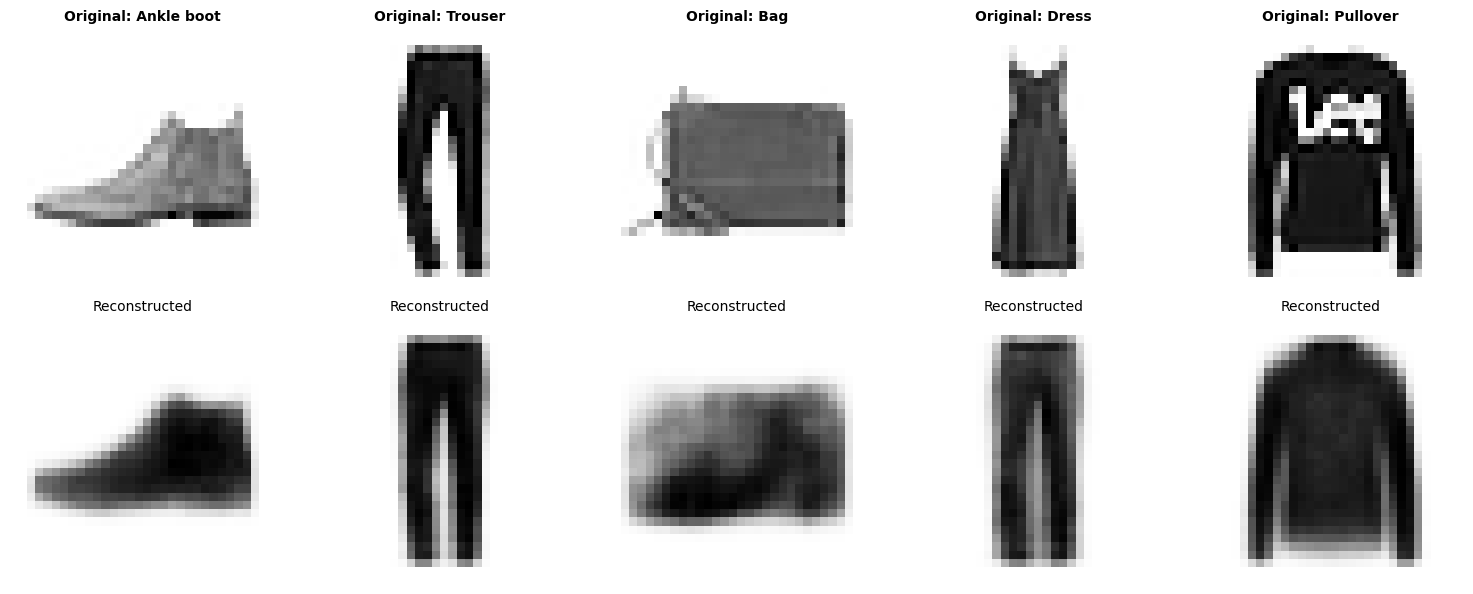

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, datasets

# ------------------------------------------------------------------
# 1. Hyperparameters & Data Preparation
# ------------------------------------------------------------------
IMAGE_SIZE = 32
CHANNELS = 1
BATCH_SIZE = 100
EMBEDDING_DIM = 2
EPOCHS = 3

# Load dataset
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()

def preprocess(imgs):
    """Normalize, pad from 28x28 to 32x32, and add channel axis."""
    imgs = imgs.astype("float32") / 255.0
    imgs = np.pad(imgs, ((0, 0), (2, 2), (2, 2)), constant_values=0.0)
    imgs = np.expand_dims(imgs, -1)
    return imgs

x_train = preprocess(x_train)
x_test = preprocess(x_test)

# ------------------------------------------------------------------
# 2. Build the Autoencoder Architecture
# ------------------------------------------------------------------
# ENCODER
encoder_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS), name="encoder_input")
x = layers.Conv2D(32, (3, 3), strides=2, activation="relu", padding="same")(encoder_input)
x = layers.Conv2D(64, (3, 3), strides=2, activation="relu", padding="same")(x)
x = layers.Conv2D(128, (3, 3), strides=2, activation="relu", padding="same")(x)

# Save feature map shape before flattening
shape_before_flattening = tuple(x.shape[1:])

x = layers.Flatten()(x)
encoder_output = layers.Dense(EMBEDDING_DIM, name="encoder_output")(x)
encoder = models.Model(encoder_input, encoder_output, name="encoder")

# DECODER
decoder_input = layers.Input(shape=(EMBEDDING_DIM,), name="decoder_input")
x = layers.Dense(int(np.prod(shape_before_flattening)))(decoder_input)
x = layers.Reshape(shape_before_flattening)(x)
x = layers.Conv2DTranspose(128, (3, 3), strides=2, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(64, (3, 3), strides=2, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
decoder_output = layers.Conv2D(
    CHANNELS, (3, 3), strides=1, activation="sigmoid", padding="same", name="decoder_output"
)(x)
decoder = models.Model(decoder_input, decoder_output, name="decoder")

# COMBINED AUTOENCODER
autoencoder = models.Model(encoder_input, decoder(encoder_output), name="autoencoder")
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

print("Model architecture built successfully!")

# ------------------------------------------------------------------
# 3. Train the Autoencoder
# ------------------------------------------------------------------
print("Training the autoencoder...")
autoencoder.fit(
    x_train,
    x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test, x_test),
)

# ------------------------------------------------------------------
# 4. Plot original vs reconstructed images for assignment submission
# ------------------------------------------------------------------
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Pick 5 representative clothing classes: Ankle boot (9), Trouser (1), Bag (8), Dress (3), Pullover (2)
selected_classes = [9, 1, 8, 3, 2]
selected_indices = [np.where(y_test == c)[0][0] for c in selected_classes]

sample_originals = x_test[selected_indices]
sample_reconstructions = autoencoder.predict(sample_originals)

# Plotting
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i in range(5):
    idx = selected_indices[i]
    label = class_names[y_test[idx]]

    # Original Image
    axes[0, i].imshow(sample_originals[i].squeeze(), cmap='Greys')
    axes[0, i].set_title(f'Original: {label}', fontsize=10, fontweight='bold')
    axes[0, i].axis('off')

    # Reconstructed Image
    axes[1, i].imshow(sample_reconstructions[i].squeeze(), cmap='Greys')
    axes[1, i].set_title('Reconstructed', fontsize=10)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()